# Logistic Regression

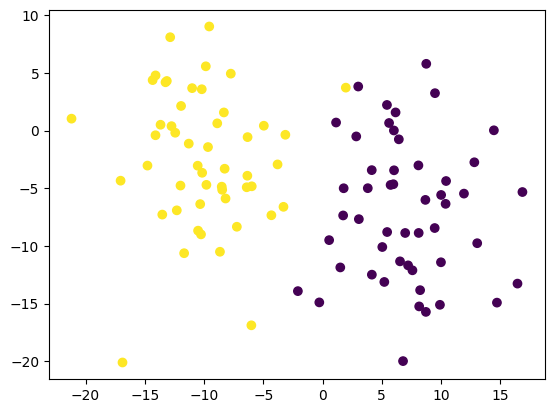

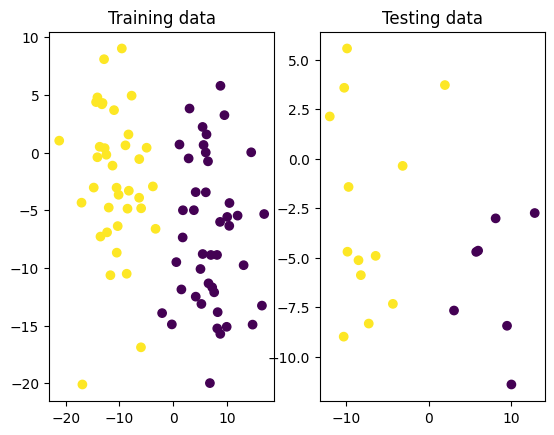

Training Method: 0
[[-0.0060453  -0.26806906  0.07092791]]
Accuracy: 95.0 %


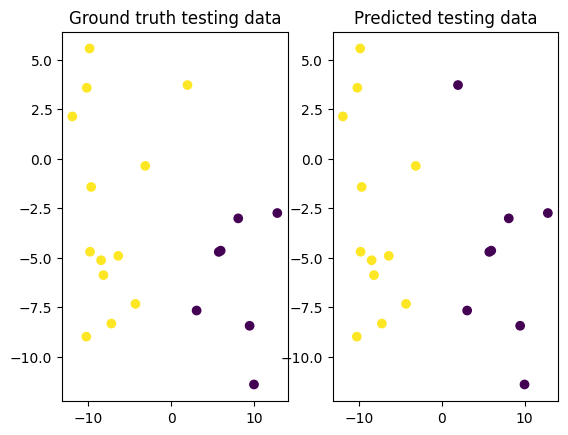

Ground truth class labels: [1 1 1 1 1 0 0 1 1 1 0 0 1 0 0 1 1 1 1 0] 
 Predicted class labels: [1 1 1 1 1 0 0 1 0 1 0 0 1 0 0 1 1 1 1 0]


In [1]:
from cv2 import ml
from sklearn.datasets import make_blobs
from sklearn import model_selection as ms
from numpy import float32
from matplotlib.pyplot import scatter, show, subplots

# Generate a dataset of 2D data points and their ground truth labels
x, y_true = make_blobs(n_samples=100, centers=2, cluster_std=5, random_state=15)

# Plot the dataset
scatter(x[:, 0], x[:, 1], c=y_true)
show()

# Split the data into training and testing sets
x_train, x_test, y_train, y_test = ms.train_test_split(x, y_true, test_size=0.2, random_state=10)

# Plot the training and testing datasets
fig, (ax1, ax2) = subplots(1, 2)
ax1.scatter(x_train[:, 0], x_train[:, 1], c=y_train)
ax1.set_title('Training data')
ax2.scatter(x_test[:, 0], x_test[:, 1], c=y_test)
ax2.set_title('Testing data')
show()

# Create an empty logistic regression model
lr = ml.LogisticRegression_create()

# Check the default training method
print('Training Method:', lr.getTrainMethod())

# Set the training method to Mini-Batch Gradient Descent and the size of the mini-batch
lr.setTrainMethod(ml.LogisticRegression_MINI_BATCH)
lr.setMiniBatchSize(5)

# Set the number of iterations
lr.setIterations(10)

# Train the logistic regressor on the set of training data
lr.train(x_train.astype(float32), ml.ROW_SAMPLE, y_train.astype(float32))

# Print the learned coefficients
print(lr.get_learnt_thetas())

# Predict the target labels of the testing data
_, y_pred = lr.predict(x_test.astype(float32))

# Compute and print the achieved accuracy
accuracy = (sum(y_pred[:, 0].astype(int) == y_test) / y_test.size) * 100
print('Accuracy:', accuracy, '%')

# Plot the ground truth and predicted class labels
fig, (ax1, ax2) = subplots(1, 2)
ax1.scatter(x_test[:, 0], x_test[:, 1], c=y_test)
ax1.set_title('Ground truth testing data')
ax2.scatter(x_test[:, 0], x_test[:, 1], c=y_pred)
ax2.set_title('Predicted testing data')
show()

# Print the ground truth and predicted class labels of the testing data
print('Ground truth class labels:', y_test, '\n',
      'Predicted class labels:', y_pred[:, 0].astype(int))

---

In [10]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression
from sklearn.metrics import mean_squared_error

X, y = make_regression(n_samples=100, n_features=5, noise=0.1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

y_pred = lasso.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

print("Coefficients:", lasso.coef_)

Mean Squared Error: 0.06362439921332456
Coefficients: [60.50305581 98.52475354 64.3929265  56.96061238 35.52928502]
